<a href="https://colab.research.google.com/github/EthanRod267/AIGuild2026/blob/main/AI_Guild_Recurrent_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

`Alex E. Sanchez`

In [ ]:
!pip install -q jax torch matplotlib numpy datasets tiktoken

In [ ]:
import jax
import jax.numpy as jnp
import jax.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import random
from collections import defaultdict
import tiktoken
from typing import Optional
from flax.training import orbax_utils
from flax.training import checkpoints
from flax.training import train_state
from flax import linen as nn
from tqdm.autonotebook import trange, tqdm
import orbax.checkpoint as orbax
import optax

In [ ]:
print(f"JAX version: {jax.__version__}")
print(f"Devices found: {jax.devices()}")

JAX version: 0.7.2
Devices found: [CudaDevice(id=0)]


In [ ]:
rng = jax.random.PRNGKey(42)

# **Recurrent Neural Networks (RNNs)**

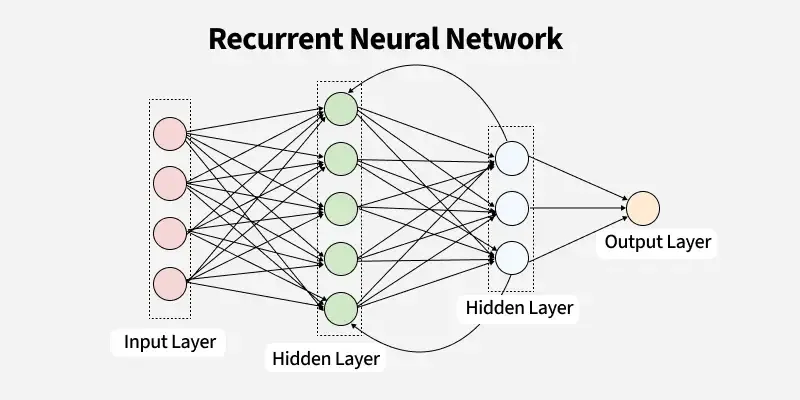

**[RNNs](https://www.geeksforgeeks.org/machine-learning/introduction-to-recurrent-neural-network/)** are neural networks specialized for *sequential modeling* tasks, like text prediction. They contain **hidden states**, which serve as a memory of the past sequences by maintaining information from previous inputs in the sequence.

The hidden state is calculated as:

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$

**Where:**

* $h_t$: The hidden state at time step $t$
* $\tanh$: The activation function
* $W_{hh}$: The weight matrix for the previous hidden state
* $h_{t-1}$: The hidden state from the previous time step
* $W_{xh}$: The weight matrix for the current input
* $x_t$: The input at the current time step
* $b_h$: The bias vector for the hidden state

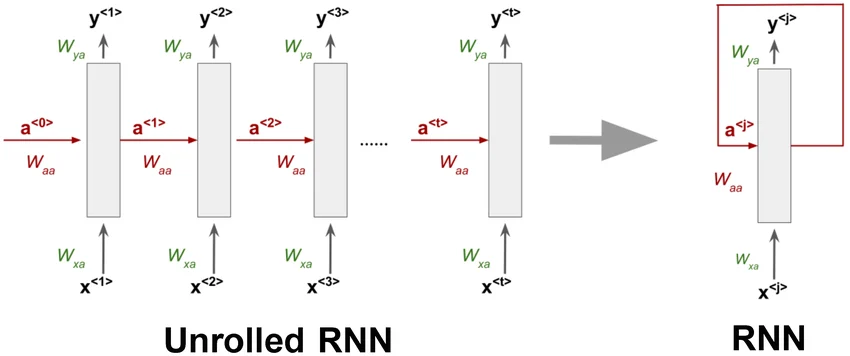

## Loading a Dataset

We'll be using a dataset called the **[Wikitext Dataset](https://huggingface.co/datasets/Salesforce/wikitext)**, which contains over 100 million tokens from a set of articles on Wikipedia.

In [ ]:
dataset = load_dataset('wikitext' , 'wikitext-2-raw-v1' , split='train')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

In [ ]:
print (dataset)

Dataset({
    features: ['text'],
    num_rows: 36718
})


We have **millions** of rows of **plain text** in our corpus. That's a mouthful of labels to train our model!

In [ ]:
def tokenize_and_batch(dataset , batch_size , seq_length , enc):
  tokenized = []
  for line in dataset['text']:
    line = line.strip()
    if line:  # Skip empty lines.
      token_ids = enc.encode(line)
      tokenized.extend(token_ids)

  # Ensure we only use complete batches
  num_batches = len(tokenized) // (batch_size * (seq_length + 1))
  tokenized = tokenized[: num_batches * batch_size * (seq_length+1)]
  token_array = np.array(tokenized).reshape((batch_size , -1))

  batches = []
  for i in range(0 , token_array.shape[1] - seq_length - 1 , seq_length):
    x = token_array[: , i : i+seq_length]
    y = token_array[: , i+1 : i+seq_length+1]
    batches.append((x,y))
  return batches

## Tokenization

If you recall, tokenization is essential for making text encoders. **Tokens** are very atomic, unique parts of words. So, instead of predicting character-by-character or word-by-word, we predict token-by-token. We will be using the **GPT-2 Encoder** in this example. It utilizes an algorithm to tokenize called the **[Byte-Pair Encoding](https://en.wikipedia.org/wiki/Byte-pair_encoding)**. Here, we read over our entire dataset and figure out which characters come close together most often, adn group them as an added, extra character in our vocabulary.

> i.e:     `aaabdaaabac`
>    => `ZabdZabac`; `(Z=aa)`=> `ZYdZYac`; `(Y=ab)`; =>`XdXac`;`(X=ZY)`
>  

In [ ]:
enc = tiktoken.get_encoding('gpt2')

In [ ]:
text_input = "Honey! Where's my Super Suit?"

token_ids = enc.encode(text_input)
print(f'Token IDs: {token_ids}')

Token IDs: [39, 1419, 0, 6350, 338, 616, 3115, 28871, 30]


In [ ]:
x = jnp.array(token_ids)[None , :]

In [ ]:
print(enc.n_vocab)

50257


## Sequence Modeling problem given text

In [ ]:
class RNN(nn.Module):
  vocab_size: int
  embed_dim: int
  hidden_size: int

  @nn.compact
  def __call__(self , x , h=None):
    batch_size, seq_length = x.shape # (batch_size , seq_length)

    # No hidden state initially, so we initialize to 0s
    if h is None:
      h = jnp.zeros((batch_size , self.hidden_size))



    # Embedding
    x_embedded = nn.Embed(num_embeddings=self.vocab_size , features=self.embed_dim)(x)

    # Define the Cell (logic for one step)
    class RNNCell(nn.Module):
      hidden_size: int
      @nn.compact
      def __call__(self, h_prev, x_t):
        h_next = jnp.tanh(nn.Dense(self.hidden_size , name='dense_x')(x_t) + nn.Dense(self.hidden_size , name='dense_h')(h_prev))
        return h_next, h_next

    # Use nn.scan to do a sequence-wide loop
    ScannedCell = nn.scan(
        RNNCell,
        variable_broadcast='params',
        split_rngs={'params': False},
        in_axes=0,
        out_axes=0
    )(hidden_size=self.hidden_size)

    # Swap axes for scan: (seq_length , batch_size , embed_dim)
    x_time_first = jnp.swapaxes(x_embedded , 0 , 1)

    # Run the scan
    h_final , outputs = ScannedCell(h , x_time_first)



    # Swap back and project to the vocabulary
    outputs = jnp.swapaxes(outputs , 0 , 1)
    logits = nn.Dense(self.vocab_size)(outputs)


    return logits , h_final

In [ ]:
def create_train_state(model , lr , batch_size , hidden_size , rng):
  dummy_x = jnp.ones((batch_size , 35) , dtype=jnp.int32)
  dummy_h = jnp.zeros((batch_size , hidden_size))

  variables = model.init(rng, dummy_x, dummy_h)
  params = variables['params']
  tx = optax.adam(lr)

  return train_state.TrainState.create(apply_fn=model.apply , params=params , tx=tx)

In [ ]:
def compute_loss(params , apply_fn , batch , h , rng):
  x , y = batch

  logits , h = apply_fn({'params': params} , x , h)
  loss = optax.softmax_cross_entropy_with_integer_labels(logits , y).mean()
  return loss , h

In [ ]:
@jax.jit
def train_step(state , batch , h , rng):
  grad_fn = jax.value_and_grad(compute_loss , has_aux=True)

  (loss,h) , grads = grad_fn(state.params , state.apply_fn , batch , h , rng)
  state = state.apply_gradients(grads=grads)

  return state , loss , h

## Training

In [ ]:
vocab_size = enc.n_vocab
embed_dim = 128
hidden_size = 256
batch_size = 32
seq_length = 35
lr = 1e-3
num_epochs = 5

In [ ]:
batches = tokenize_and_batch(dataset , batch_size , seq_length , enc)

In [ ]:
checkpoint_dir = '/checkpoints/rnn-checkpoints'

options = orbax.CheckpointManagerOptions(max_to_keep=3 , create=True)

checkpoint_manager = orbax.CheckpointManager(
    checkpoint_dir,
    orbax.PyTreeCheckpointer(),
    options=options
)

In [ ]:
x_list , y_list = zip(*batches)

# Shape: (num_batches , batch_size , seq_length)
x_all = jnp.stack(x_list)
y_all = jnp.stack(y_list)

In [ ]:
@jax.jit
def train_epoch(state , x_batches , y_batches , init_h , rng):
  def step_fn(carry , batch_data):
    current_state, current_h, current_rng = carry
    x , y = batch_data

    new_rng , subkey = jax.random.split(current_rng)


    # Loss and Gradient Calculation
    grad_fn = jax.value_and_grad(compute_loss , has_aux=True)
    (loss , h_next) , grads = grad_fn(current_state.params , current_state.apply_fn , (x,y) , current_h , subkey)

    new_state = current_state.apply_gradients(grads=grads)

    return (new_state , h_next , new_rng) , loss

  # Scan over all batches
  carry_init = (state , init_h , rng)
  (final_state , final_h , final_rng) , losses = jax.lax.scan(step_fn , carry_init , (x_batches , y_batches))

  return final_state , jnp.mean(losses) , final_h , final_rng

In [ ]:
model = RNN(vocab_size , embed_dim , hidden_size)
state = create_train_state(model , lr , batch_size , hidden_size , rng)
h = jnp.zeros((batch_size , hidden_size))

# Training loop
for epoch in trange(num_epochs):
  state , avg_loss , h , rng = train_epoch(state , x_all , y_all , h , rng)
  print(f'Epoch {epoch+1} | Loss: {avg_loss:.4f}')

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 | Loss: 6.1977
Epoch 2 | Loss: 5.2502
Epoch 3 | Loss: 4.8137
Epoch 4 | Loss: 4.5057
Epoch 5 | Loss: 4.2619


In [ ]:
save_args = orbax_utils.save_args_from_target(state)
checkpoints.save_checkpoint(checkpoint_dir , state , step=epoch , overwrite=True)

'/checkpoints/rnn-checkpoints/checkpoint_4'

In [ ]:
seed_text = "Once upon a time, "

In [ ]:
h = jnp.zeros((1 , hidden_size))

seed_tokens = enc.encode(seed_text)
print(f'Seed Tokens: {seed_tokens}')

generated_tokens = list(seed_tokens)

# We need to pass the entire seed sequence to update the hidden state h
x_seed = jnp.array(seed_tokens)[None , :]  # Shape: (1 , seed_length)
_ , h = model.apply({'params': state.params} , x_seed , h)

current_token = seed_tokens[-1]
temp = 1.0

Seed Tokens: [7454, 2402, 257, 640, 11, 220]


In [ ]:
for _ in range(100):
  x = jnp.array([[current_token]])

  # Logits shape is (1 , 1 , vocab_size)
  logits , h = model.apply({'params': state.params} , x , h)
  next_logits = logits[0 , -1 , :]

  adjusted_logits = next_logits / temp

  rng , subkey = jax.random.split(rng)
  current_token = int(jax.random.categorical(subkey , adjusted_logits))
  generated_tokens.append(current_token)

In [ ]:
generated_text = enc.decode(generated_tokens)

In [ ]:
generated_text

'Once upon a time, incher priests ( rapos Molosis ) iseches of fear of the fort and has discovered unique traditions in governance of three compounds of S. macern . ჻ ( Spanish : جn Nuskhuri Sector = =Stocirmary , Mogadishu had formed significantly under the command of Flotsery and had hidden dishes , including Rhodesian country Latising units . During the north in the mid @-@ Song army would harass the offensive shootings in AlbanyA year before'

## But what happened?

Sure, I'm reading English, but there doesn't seem to be much sense to what the model is doing. That's because backpropagation works **terribly** through time. We call that the **vanishing gradient problem**

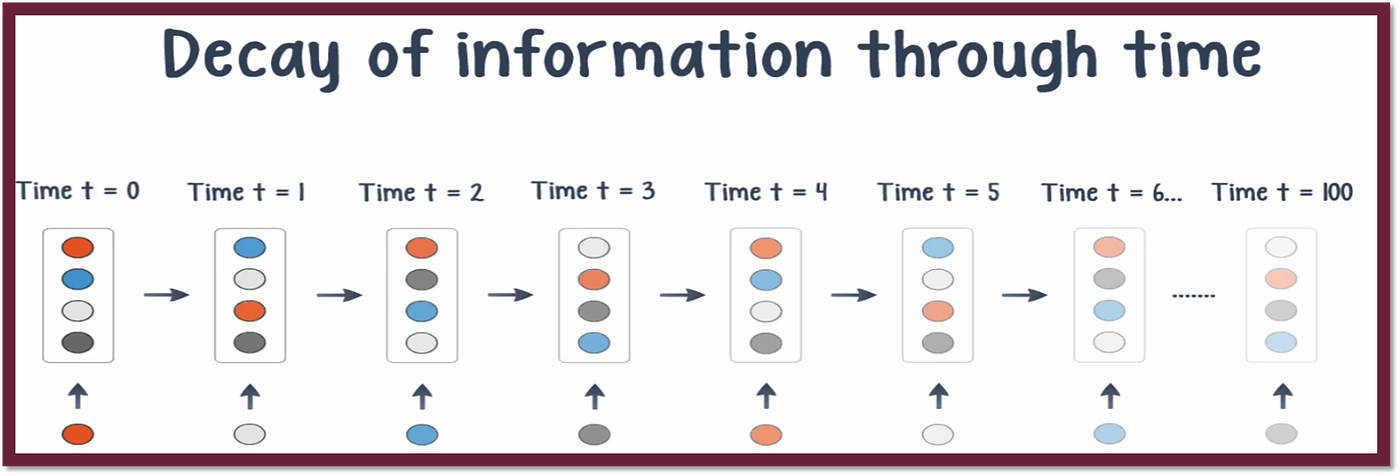

When you backpropagate through many time steps, the gradients – essentially the signals that tell the network how to update its weights – can become extremely small. In mathematical terms, you're multiplying many small numbers together (each derivative from a time step), and this product tends to shrink exponentially. As a result, the network struggles to learn dependencies from earlier time steps because the updates become negligible. This is why your model might capture short-term patterns, but lose the context needed for coherent long-term sequences.

# **Long Short-Term Memory (LSTMs) & Gated Recurrent Unit (GRUs)**

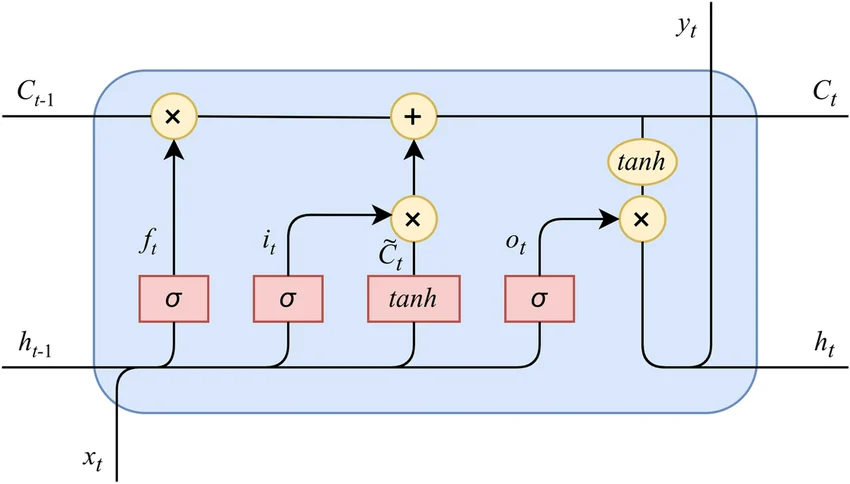

**We will focus primarily on LSTMs.** LSTMs introduced 4 different components to an RNN cell, that made it handle the vanishing gradient problem more effectively by allowing relevant information to be kept and other information to be disgarded. The new mechanisms were the *Cell State*, *Forget Gate*, *Input Gate*, and *Output Gate*.

Due to the **Cell State Update** being **additive** rather than purely multiplication, the gradient can flow through the Cell state without being totally zeroed.

$$
\begin{aligned}
f_t &= \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \quad &\text{(forget gate)}\\
i_t &= \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad &\text{(input gate)}\\
o_t &= \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \quad &\text{(output gate)}\\
\tilde{c}_t &= \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) \quad &\text{(cell candidate)}\\
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \quad &\text{(cell state update)}\\
h_t &= o_t \odot \tanh(c_t) \quad &\text{(hidden state update)}
\end{aligned}
$$

In [ ]:
def create_initial_hidden_state(batch_size, hidden_size):
    return (jnp.zeros((batch_size, hidden_size)),
            jnp.zeros((batch_size, hidden_size)))

In [ ]:
class LSTM(nn.Module):
  vocab_size: int
  embed_dim: int
  hidden_size: int
  num_layers: int = 3

  def setup(self):
    # Embedding layer: converts token IDs to embeddings
    self.embedding = nn.Embed(
        num_embeddings=self.vocab_size,
        features=self.embed_dim
    )

    # Creating multiple scanned LSTM layers using list comprehension
    self.lstm_layers = [
        nn.scan(
            nn.OptimizedLSTMCell,
            variable_broadcast='params',
            split_rngs={'params': False},
            in_axes=1,
            out_axes=1,
            length=None,
            reverse=False
        )(features=self.hidden_size)
        for _ in range(self.num_layers)
    ]

    # Project each timestep's hidden state to vocab logits
    self.output_proj = nn.Dense(self.vocab_size)

  @nn.remat
  def __call__(self , x: jnp.ndarray , init_carries=None):
    batch_size , seq_length = x.shape

    # Embed the token IDs
    x = self.embedding(x)  # batch_size , seq_length , embed_dim

    if init_carries is None:
      init_carries = [create_initial_hidden_state(batch_size, self.hidden_size) for _ in range(self.num_layers)]

    new_carries = []

    for lstm_layer,carry in zip(self.lstm_layers , init_carries):
      new_carry , x = lstm_layer(carry , x)
      new_carries.append(new_carry)

    logits = self.output_proj(x)  # batch_size , seq_length , vocab_size
    return logits , new_carries

In [ ]:
def create_train_state(model , lr , batch_size , hidden_size , rng):
  dummy_x = jnp.ones((batch_size , seq_length) , dtype=jnp.int32)

  params = model.init(rng , dummy_x)['params']

  tx = optax.adam(lr)

  return train_state.TrainState.create(
      apply_fn=model.apply,
      params=params,
      tx=tx
  )

In [ ]:
@jax.jit
def update_fn(state , batch):
  def loss_fn(params):
    # x: (batch_size , seq_length)
    # y: (batch_size , seq_length)
    x , y = batch

    # logits: (batch_size , seq_length , vocab_size)
    logits , _ = state.apply_fn({'params': params} , x)
    loss = optax.softmax_cross_entropy_with_integer_labels(logits , y).mean()
    return loss

  loss , grads = jax.value_and_grad(loss_fn)(state.params)
  new_state = state.apply_gradients(grads=grads)
  return new_state , loss

In [ ]:
vocab_size = enc.n_vocab
embed_dim = 128
hidden_size = 256
batch_size = 32
seq_length = 35
learning_rate = 1e-3
num_epochs = 5

In [ ]:
model = LSTM(vocab_size , embed_dim , hidden_size , num_layers=3)
state = create_train_state(model , lr , batch_size , hidden_size , rng)

In [ ]:
for epoch in trange(num_epochs):
  for batch in tqdm(batches):
    _ , rng = jax.random.split(rng)
    state , loss = update_fn(state , batch)

  print(f'Epoch {epoch+1} | Loss: {loss:.4f}')

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/2095 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
checkpoint_dir = '/checkpoints/lstm-checkpoints'

options = orbax.CheckpointManagerOptions(max_to_keep=3 , create=True)
checkpoint_manager = orbax.CheckpointManager(
    checkpoint_dir,
    orbax.PyTreeCheckpointer(),
    options=options
)

In [ ]:
save_args = orbax_utils.save_args_from_target(state)
checkpoints.save_checkpoint(checkpoint_dir , state , step=epoch , overwrite=True)

In [ ]:
seed_text = "Once upon a time, "
seed_tokens = enc.encode(seed_text)
print("Seed tokens:", seed_tokens)

In [ ]:
h = create_initial_hidden_state(1 , hidden_size)

x_seed = jnp.array(seed_tokens , dtype=jnp.int32)[None , :]  # Shape (1 , seq_length)
logits , carries = model.apply({'params': state.params} , x_seed)

current_token = seed_tokens[-1]
generated_tokens = seed_tokens.copy()
temp = 0.8

loop_rng = jax.random.PRNGKey(42)

for _ in tqdm(range(100)):
    x_input = jnp.array([[current_token]], dtype=jnp.int32)

    logits, carries = model.apply({'params': state.params}, x_input, init_carries=carries)

    next_token_logits = logits[0, 0, :]

    adjusted_logits = next_token_logits / temp

    loop_rng, subkey = jax.random.split(loop_rng)
    current_token = int(jax.random.categorical(subkey, adjusted_logits))

    generated_tokens.append(current_token)

In [ ]:
generated_text = enc.decode(generated_tokens)
generated_text

---

# **Google JAX Tutorial!**

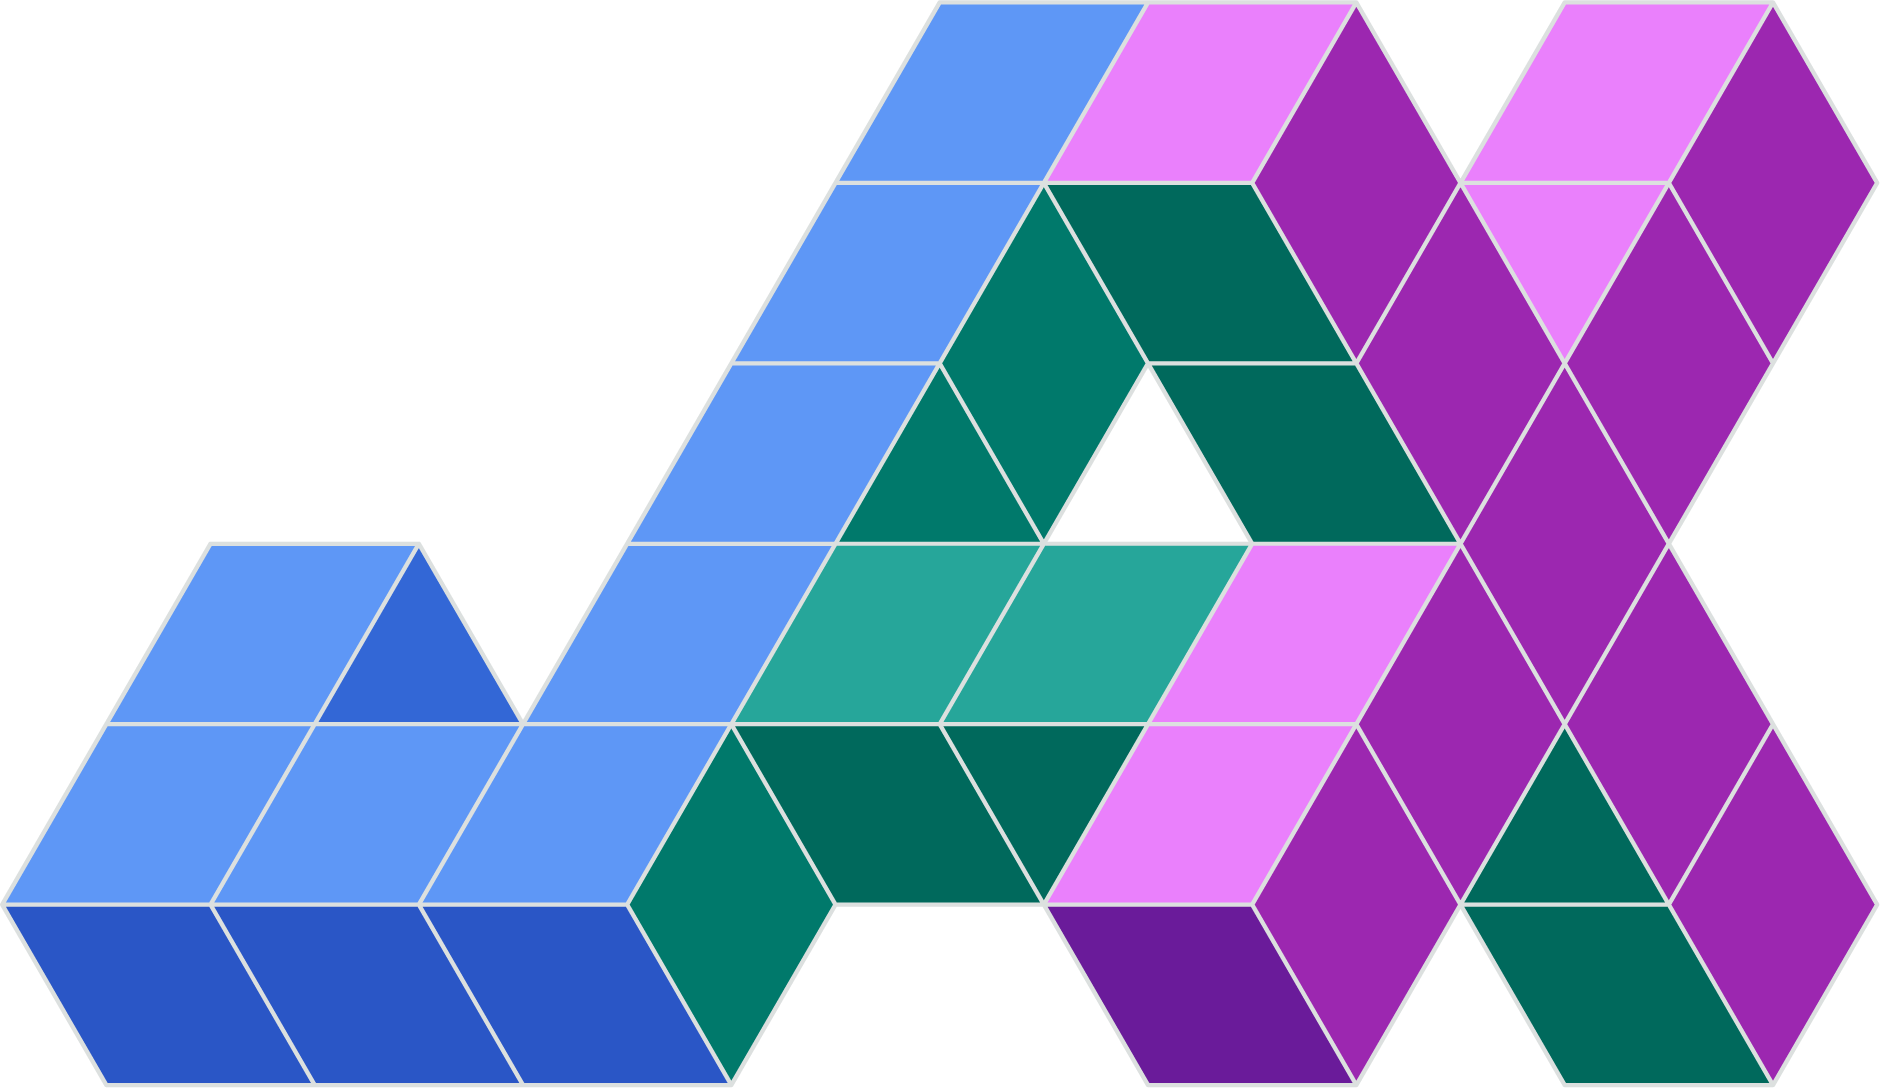

**What is JAX?**

JAX is a functional-programming-based autodiff engine. It takes familiar NumPy syntax but combines it with **XLA (Accelerated Linear Algebra)** and **Vectorization**, which allows it to compile extremely fast on TPUs and automatically batch operations without explicitly needed a `for` loop.

In [ ]:
import jax
import jax.numpy as jnp
import numpy as np

x_np = np.array([1, 2, 3])
x_jnp = jnp.array([1, 2, 3])

print(f'NumPy: {x_np}')
print(f'JAX: {x_jnp}')

NumPy: [1 2 3]
JAX: [1 2 3]


In [ ]:
print(f'JAX Math: {jnp.dot(x_jnp , x_jnp)}')

JAX Math: 14


## Immutability

In PyTorch or NumPy, if you want to change the first element of an array, you just reassign it: `x[0] = 10`.

However, JAX arrays are **immutable**, meaning that once created, they cannot be changed in place.

In [ ]:
# NumPy way
x_np = np.array([1 , 2 , 3])
print(f'OG NumPy: {x_np}')
x_np[0] = 10
print(f'Mutated NumPy: {x_np}')

OG NumPy: [1 2 3]
Mutated NumPy: [10  2  3]


In [ ]:
# JAX way
x_jnp = jnp.array([1 , 2 , 3])
print(f'OG JAX: {x_jnp}')

OG JAX: [1 2 3]


In [ ]:
# The fix is to use .at[].set() syntax
# This returns a brand new array, doesn't change x_jnp

new_x_jnp = x_jnp.at[0].set(10)

print(f'Old JAX Array: {x_jnp}')
print(f'New JAX Array: {new_x_jnp}')

Old JAX Array: [1 2 3]
New JAX Array: [10  2  3]


## Randomness

In PyTorch, we would set a global seed `torch.manual_seed()`. Every time we called a random function, the global state would update under the hood.

Because JAX requires functions to be pure, **there is no global random state**. You have to explicitly manage and split your random keys.

In [ ]:
# Create a Pseudo Random Number Generator (PRNG) key
rng = jax.random.PRNGKey(42)

In [ ]:
print("Same key 1:", jax.random.normal(rng , (3,)))
print("Same key 2:", jax.random.normal(rng , (3,)))

Same key 1: [-0.02830462  0.46713185  0.29570296]
Same key 2: [-0.02830462  0.46713185  0.29570296]


In [ ]:
# We must split the key every time we need new random numbers
rng , subkey = jax.random.split(rng)
print(f'Using subkey: {jax.random.normal(subkey , (3,))}')

Using subkey: [ 0.60576403  0.7990441  -0.908927  ]


In [ ]:
# Split again if more is needed!
rng , subkey2 = jax.random.split(rng)
print(f'Using subkey2: {jax.random.normal(subkey2 , (3,))}')

Using subkey2: [-0.21089035 -1.3627948  -0.04500385]


## JAX Superpowers

* **`jax.grad`**: Automatically computes the derivative of your function.
- **`jax.jit`**: Just-In-Time compiles your function to be extremely fast.
- **`jax.vmap`**: Vectorizes your function (applies to a batch of inputs automatically).

In [ ]:
'''ADD PMAP'''

In [ ]:
# Lets define a simple function: f(x) = x^3 + 2x
def f(x):
  return x**3 + 2*x

In [ ]:
# GRADIENT: the derivative is f'(x) = 3x^2 + 2
# f'(2.0) = 3(2.0)^2 + 2 = 12 + 2 = 14
df_dx = jax.grad(f)
df_dx(2.0)

Array(14., dtype=float32, weak_type=True)

In [ ]:
# JIT COMPILATION: making it fast
fast_f = jax.jit(f)

In [ ]:
# VMAP: Apply to a batch without using a for-loop
batch_of_xs = jnp.array([1.0 , 2.0 , 3.0])

# f(batch_of_xs) works here normally, but for more complex functions, vmap is a lifesaver
batched_f = jax.vmap(f)
print(batched_f(batch_of_xs))

[ 3. 12. 33.]


### **[Final Colab](https://colab.research.google.com/drive/1y4Zs0aGAeA2Ony9hCeG4ez_Mg_z8bN_J?usp=sharing)**